In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import glob
import os

folder_path1 = "/content/drive/MyDrive/homer_bart/training_set/bart"
folder_path2 = "/content/drive/MyDrive/homer_bart/training_set/homer"
folder_path3 = "/content/drive/MyDrive/homer_bart/test_set/bart"
folder_path4 = "/content/drive/MyDrive/homer_bart/test_set/homer"

In [5]:
bart_training_set_img = glob.glob(folder_path1 + "/*")
homer_training_set_img = glob.glob(folder_path2 + "/*")
bart_test_img = glob.glob(folder_path3 + "/*")
homer_test_img = glob.glob(folder_path4 + "/*")

In [6]:
print(f'bart_training_set_img: {len(bart_training_set_img)}')
print(f'homer_training_set_img: {len(homer_training_set_img)}')
print(f'bart_test_img: {len(bart_test_img)}')
print(f'homer_test_img: {len(homer_test_img)}')


bart_training_set_img: 132
homer_training_set_img: 83
bart_test_img: 28
homer_test_img: 26


In [7]:
bart = cv2.imread(bart_training_set_img[0])
homer = cv2.imread(homer_training_set_img[0])

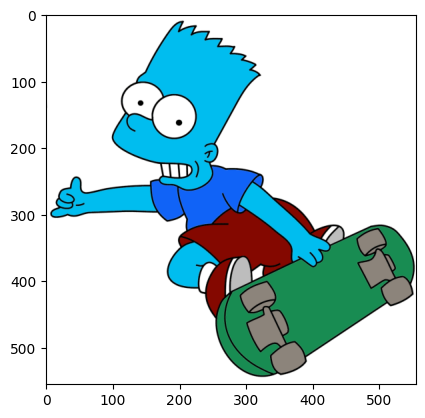

In [8]:
plt.imshow(bart)

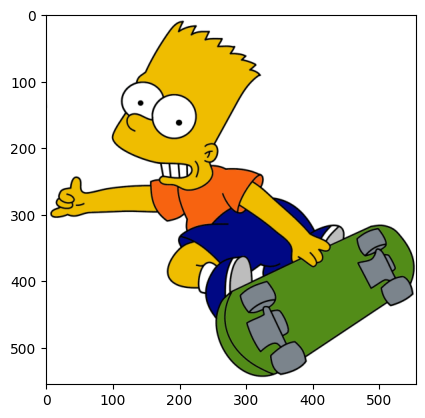

In [9]:
rgb_bart = cv2.cvtColor(bart, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_bart)

In [10]:
type(rgb_bart)
type(bart)

numpy.ndarray

In [11]:
bart.shape

(555, 555, 3)

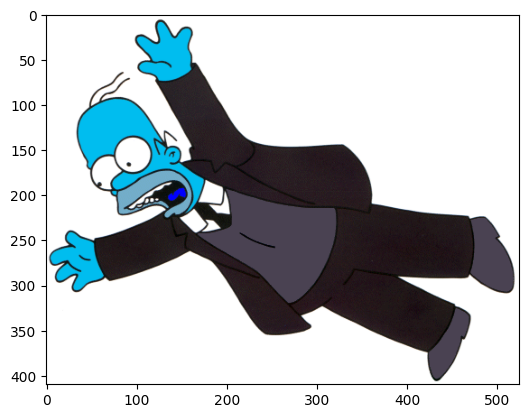

In [12]:
plt.imshow(homer)

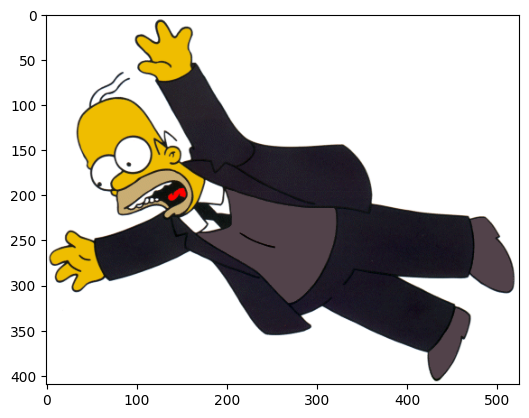

In [13]:
rgb_homer = cv2.cvtColor(homer, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_homer)

In [14]:
homer.shape

(410, 525, 3)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [16]:
imge_gen = ImageDataGenerator(rotation_range=30, width_shift_range=0.1, height_shift_range=0.1, shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

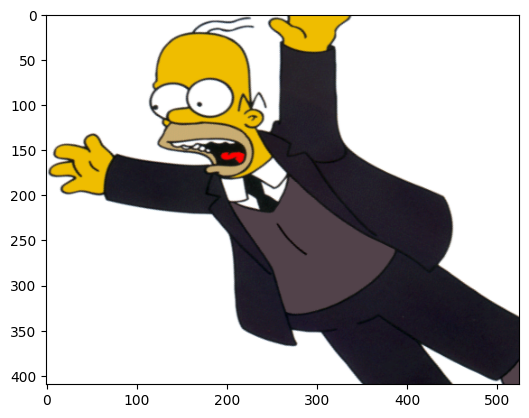

In [17]:
plt.imshow(imge_gen.random_transform(rgb_homer))

In [18]:
imge_gen.flow_from_directory('/content/drive/MyDrive/homer_bart/training_set')

Found 215 images belonging to 2 classes.


In [19]:
imge_gen.flow_from_directory('/content/drive/MyDrive/homer_bart/test_set')

Found 54 images belonging to 2 classes.


In [20]:
from matplotlib import image
##width,height,channels
image_shape = (130,130,3)

In [21]:
image_shape[:2]

(130, 130)

In [22]:
## Model building
from keras.models import Sequential
from keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [23]:
from ast import mod
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))

model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
batch_size = 16

train_image_gen = imge_gen.flow_from_directory('/content/drive/MyDrive/homer_bart/training_set',
                                               target_size=image_shape[:2],
                                               batch_size=batch_size, class_mode='binary')

Found 215 images belonging to 2 classes.


In [25]:
test_imge_gen = imge_gen.flow_from_directory('/content/drive/MyDrive/homer_bart/test_set',
                                                  target_size=image_shape[:2],
                                               batch_size=batch_size, class_mode='binary')

Found 54 images belonging to 2 classes.


In [26]:
train_image_gen.class_indices

{'bart': 0, 'homer': 1}

In [27]:
results = model.fit(train_image_gen,epochs=5,validation_data=test_imge_gen)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 110s 8s/step - accuracy: 0.5349 - loss: 165.3643 - val_accuracy: 0.5370 - val_loss: 3.5427
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 600ms/step - accuracy: 0.6140 - loss: 0.9978 - val_accuracy: 0.7593 - val_loss: 0.4831
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 577ms/step - accuracy: 0.6605 - loss: 0.6148 - val_accuracy: 0.6852 - val_loss: 0.6388
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 656ms/step - accuracy: 0.7116 - loss: 0.5350 - val_accuracy: 0.7037 - val_loss: 0.5685
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 522ms/step - accuracy: 0.7395 - loss: 0.4803 - val_accuracy: 0.7963 - val_loss: 0.4960


In [28]:
test_loss,test_accuracy = model.evaluate(test_imge_gen)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.7222 - loss: 0.5961


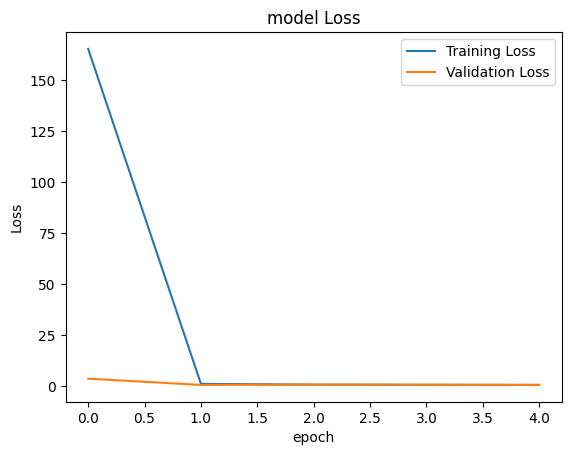

In [29]:
## Evalution performance
plt.plot(results.history['loss'], label="Training Loss")
plt.plot(results.history['val_loss'], label="Validation Loss")
plt.legend()
plt.title('model Loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.show()